# Data Visualization with matplotlib
* in lesson 19 we learned how to crunch numbers fast with numpy and organize them into tables with pandas - but a table of a thousand numbers is hard for a human brain to actually understand
* a good chart reveals patterns, trends and outliers INSTANTLY that would take forever to spot by scrolling through raw numbers - this is what data visualization is for
* **matplotlib** is THE foundational plotting library in python - its been around since the mid 2000s and almost every other python plotting tool is either built directly on top of it or deeply inspired by its API
* pandas' own `.plot()` method (which we will use later in this lesson) is literally a thin wrapper AROUND matplotlib - so learning matplotlib first means you already understand whats happening under the hood everywhere else

In [1]:
# the universal alias for matplotlib's main plotting module is "plt" - just like "np" for numpy and "pd" for pandas
import matplotlib.pyplot as plt
import numpy as np   # we will need numpy for generating some example data
import pandas as pd  # and pandas for the "plot straight from a DataFrame" part later

# a fixed random seed - this makes any "random" data below 100% reproducible
# (without this, everyone running this notebook would get slightly different numbers and slightly different charts)
np.random.seed(42)

## the basic anatomy of a matplotlib plot
* `plt.plot(x, y)` draws a line plot - the most basic building block, connecting the given x/y points with a line
* `plt.title()`, `plt.xlabel()`, `plt.ylabel()` add text labels so anyone looking at the chart (not just us) understands what it shows
* `plt.legend()` shows a little box explaining what each line/color means (needs a `label=` on the plot call to have something to show)
* `plt.show()` actually displays the figure - without it some environments wont render anything at all (jupyter is usually forgiving here, but its good habit to always call it)

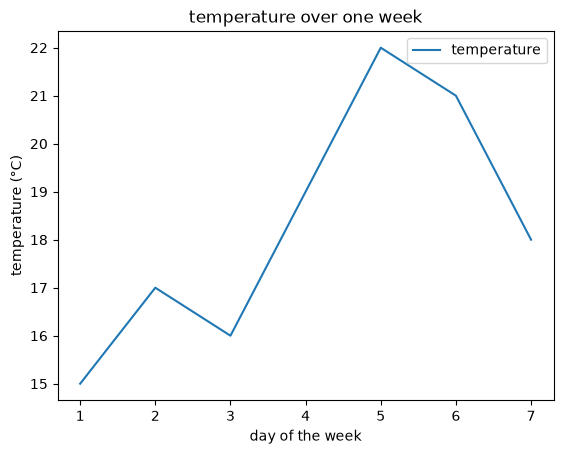

In [2]:
# some simple example data - "days" on the x-axis, "temperature" on the y-axis
days = [1, 2, 3, 4, 5, 6, 7]
temperature = [15, 17, 16, 19, 22, 21, 18]  # a made-up week of temperatures in celsius

plt.plot(days, temperature, label="temperature")  # the actual line plot - x values, then y values
plt.title("temperature over one week")             # a title so we know what we are looking at
plt.xlabel("day of the week")                       # label for the x-axis
plt.ylabel("temperature (\u00b0C)")                     # label for the y-axis
plt.legend()                                        # shows the "temperature" label we gave to plot() above
plt.show()                                          # renders the figure - in jupyter this shows up as an image output

## the four classic chart types
* **line plot** - great for showing a value changing over time/sequence (like the temperature example above)
* **bar chart** - great for comparing distinct categories against each other (`plt.bar(categories, values)`)
* **scatter plot** - great for showing the relationship between two numeric variables (`plt.scatter(x, y)`)
* **histogram** - great for showing the DISTRIBUTION of many values at once, e.g. how often each range of values occurs (`plt.hist(values, bins=...)`)

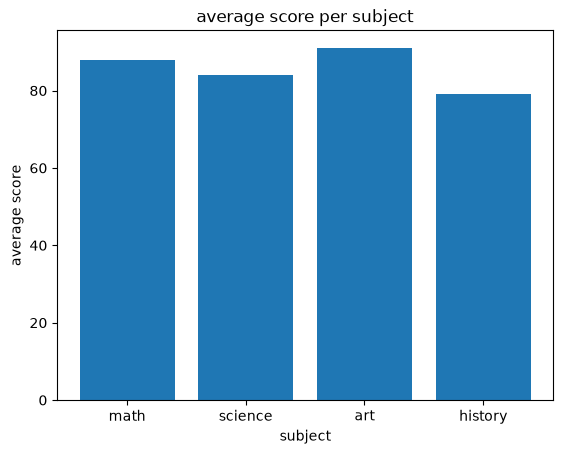

In [3]:
# bar chart - callback to lesson 19's students/subjects style, but comparing average score per subject
subjects = ["math", "science", "art", "history"]
average_scores = [88, 84, 91, 79]  # made-up average scores per subject

plt.bar(subjects, average_scores)                 # plt.bar() takes the category labels and their values
plt.title("average score per subject")
plt.xlabel("subject")
plt.ylabel("average score")
plt.show()

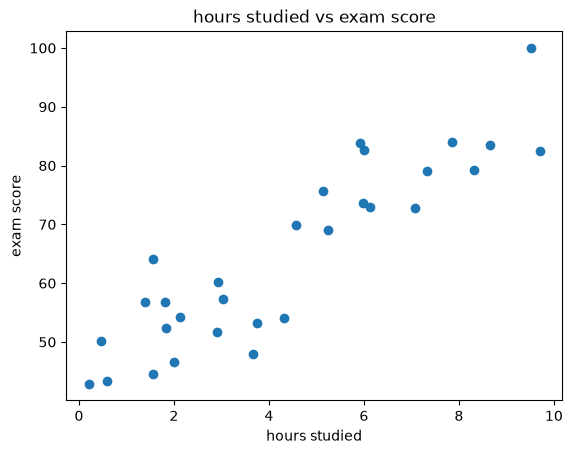

In [4]:
# scatter plot - lets fake up "hours studied" vs "exam score" for 30 students, with a rough positive correlation
np.random.seed(42)  # re-seeding here too, so this cell is reproducible even if run on its own
hours_studied = np.random.uniform(0, 10, 30)                      # 30 random values between 0 and 10 hours
exam_score = hours_studied * 6 + np.random.normal(0, 8, 30) + 40  # roughly "more hours --> higher score", plus some random noise

plt.scatter(hours_studied, exam_score)  # plt.scatter() just needs matching x and y arrays, no lines connecting them
plt.title("hours studied vs exam score")
plt.xlabel("hours studied")
plt.ylabel("exam score")
plt.show()
# notice the rough upward trend - more studying tends to mean a higher score, even though its noisy/not a perfect line

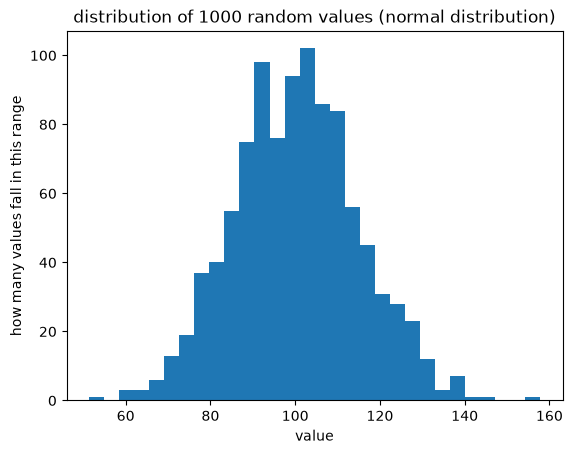

In [5]:
# histogram - the DISTRIBUTION of 1000 normally-distributed random numbers (think: heights, test scores, measurement errors, ...)
np.random.seed(42)                                   # reproducible randomness, as always
random_values = np.random.normal(loc=100, scale=15, size=1000)  # 1000 values, centered around 100, spread of 15

plt.hist(random_values, bins=30)  # bins= controls how many "buckets" the range gets split into - more bins = finer detail
plt.title("distribution of 1000 random values (normal distribution)")
plt.xlabel("value")
plt.ylabel("how many values fall in this range")
plt.show()
# the classic "bell curve" shape - most values cluster around the center (100), fewer values further out

## subplots - several charts, one figure
* `plt.subplots(rows, cols)` creates a grid of individual chart "axes" inside ONE figure - handy for comparing several charts side by side
* it returns two things: the overall `fig` (the whole figure/window) and `ax` (an array of individual plot areas, one per grid cell)
* instead of calling `plt.bar(...)` etc directly, we now call the same methods ON the specific `ax` slot we want to draw into, e.g. `ax[0].bar(...)`

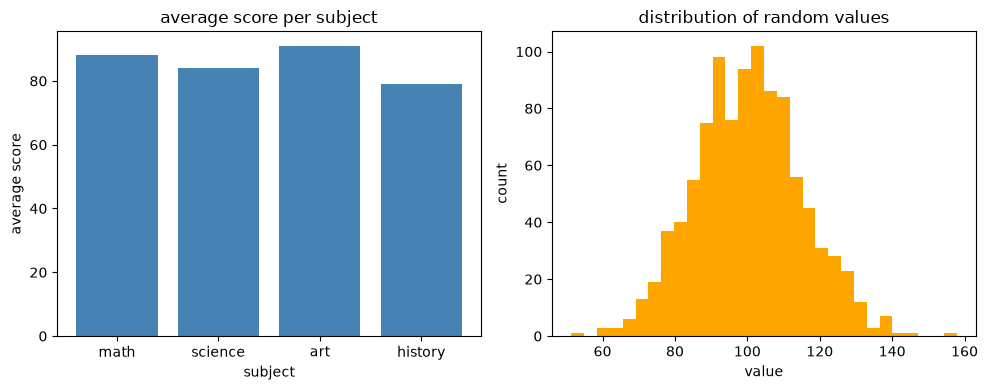

In [6]:
# lets put the bar chart and the histogram from above side by side, in one figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(10, 4))  # figsize=(width, height) in inches - without it the default is quite small

# left subplot (index 0) - the subject bar chart again
ax[0].bar(subjects, average_scores, color="steelblue")  # color= just picks a specific color instead of matplotlib's default
ax[0].set_title("average score per subject")             # note: on an ax object its set_title()/set_xlabel(), not title()/xlabel()
ax[0].set_xlabel("subject")
ax[0].set_ylabel("average score")

# right subplot (index 1) - the random-values histogram again
ax[1].hist(random_values, bins=30, color="orange")
ax[1].set_title("distribution of random values")
ax[1].set_xlabel("value")
ax[1].set_ylabel("count")

plt.tight_layout()  # automatically adds spacing so the two subplots titles/labels dont overlap each other
plt.show()

## customizing appearance - a practical subset, not an exhaustive style guide
* **colors** - pass `color="red"` / `color="#3366cc"` / one of many named colors to almost any plotting call
* **marker styles** - `marker="o"` (circles), `marker="x"`, `marker="^"` (triangles), ... useful especially on line/scatter plots to make individual points visible
* **figure size** - `figsize=(width, height)` in inches, either on `plt.figure(figsize=...)` or `plt.subplots(..., figsize=...)`
* **grid lines** - `plt.grid(True)` adds light background grid lines, often makes it easier to read exact values off a chart

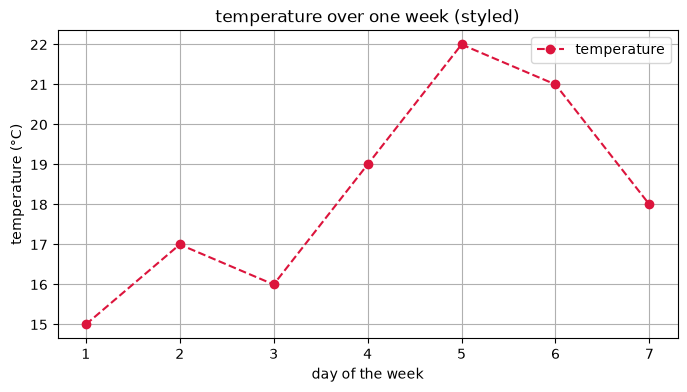

In [7]:
# combining a few customizations on our original temperature line plot
plt.figure(figsize=(8, 4))                                    # a slightly wider figure than the default
plt.plot(days, temperature, color="crimson", marker="o", linestyle="--", label="temperature")
# color="crimson" -> a specific red shade, marker="o" -> a visible dot at each data point, linestyle="--" -> dashed line instead of solid
plt.title("temperature over one week (styled)")
plt.xlabel("day of the week")
plt.ylabel("temperature (\u00b0C)")
plt.legend()
plt.grid(True)  # light grid lines in the background, makes it easier to read off approximate values
plt.show()

## plotting directly from pandas - `.plot()`
* every pandas `Series` and `DataFrame` has a built-in `.plot()` method - it internally calls matplotlib for us, so we dont need `plt.plot()`/`plt.bar()` by hand at all
* `.plot()` returns a normal matplotlib `Axes` object (the exact same kind of object `plt.subplots()` gives us) - proof that its "just" a convenient wrapper, not some separate parallel plotting system
* `kind="line"` (the default), `kind="bar"`, `kind="scatter"`, `kind="hist"`, ... lets us pick the chart type with one keyword argument

<class 'matplotlib.axes._axes.Axes'>


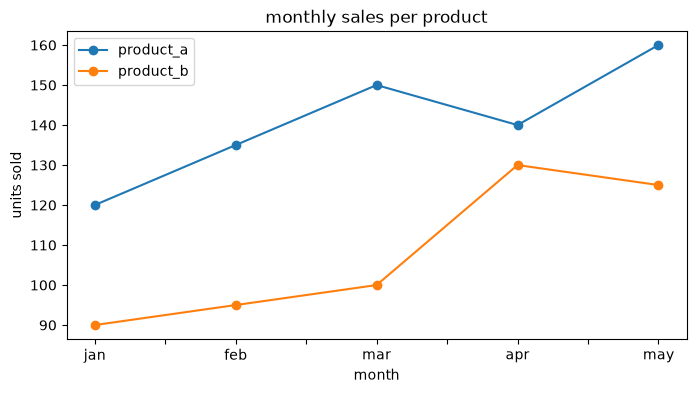

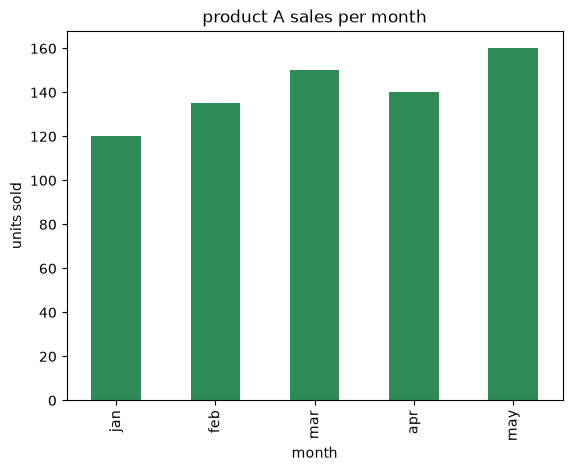

In [8]:
# building a small DataFrame, same style as lesson 19's students table
sales = pd.DataFrame({
    "month": ["jan", "feb", "mar", "apr", "may"],
    "product_a": [120, 135, 150, 140, 160],
    "product_b": [90, 95, 100, 130, 125],
})
sales = sales.set_index("month")  # using "month" as the index means pandas will use it as the x-axis automatically

# plotting a whole DataFrame at once - one line per numeric column, completely automatic
axes = sales.plot(kind="line", figsize=(8, 4), marker="o")  # .plot() understands the same marker=/figsize= keywords as plt does
print(type(axes))  # this really is a matplotlib.axes.Axes object - .plot() is "just" matplotlib underneath
plt.title("monthly sales per product")   # we can still mix in plain plt.* calls afterwards, they affect the same current figure
plt.ylabel("units sold")
plt.show()

# a bar chart straight from a Series - just the product_a column, compared per month
sales["product_a"].plot(kind="bar", color="seagreen", title="product A sales per month")
plt.ylabel("units sold")
plt.show()

## saving a chart to a file
* `plt.savefig("filename.png")` saves whatever is currently drawn to an actual image file on disk, instead of (or in addition to) showing it
* it must be called BEFORE `plt.show()` - `plt.show()` can clear/reset the current figure in some environments, so call `savefig()` first to be safe
* we save one here just to prove it works, then immediately clean it up again - we dont want to leave generated image files lying around in the repo

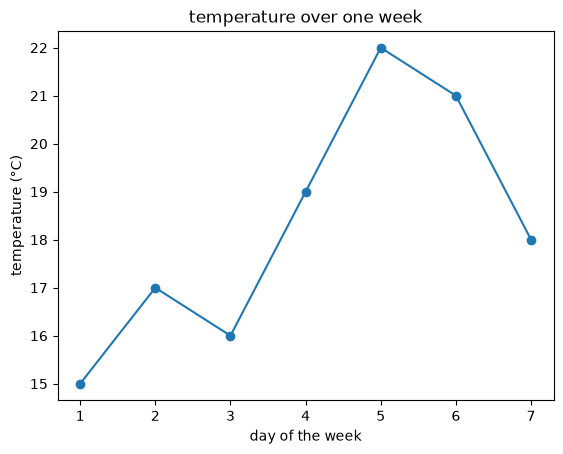

file exists on disk? True
file exists after cleanup? False


In [9]:
import os

plt.plot(days, temperature, marker="o")
plt.title("temperature over one week")
plt.xlabel("day of the week")
plt.ylabel("temperature (\u00b0C)")
plt.savefig("demo_chart.png")  # writes the current figure to disk as a png - call this BEFORE plt.show()
plt.show()

print("file exists on disk?", os.path.exists("demo_chart.png"))  # proves savefig() actually created a real file

os.remove("demo_chart.png")  # cleaning up the demo file, we dont want to leave it in the repo
print("file exists after cleanup?", os.path.exists("demo_chart.png"))

## whats next?
* **seaborn** is a higher-level statistical-plotting library built directly on top of matplotlib - it has much nicer default styling and makes common statistical charts (distributions, correlations, categorical comparisons) a one-liner instead of several `plt.*` calls
* **plotly** and **bokeh** go a different direction: they build fully INTERACTIVE, browser-based charts (zoom, hover-tooltips, pan) instead of static images - great when a chart needs to live inside a web page/dashboard and be interactive, rather than sit in a static report or notebook
* we wont install or run either of these here, but its useful to know matplotlib is the common foundation underneath most of the python plotting world

## quick comparison to other languages
* matplotlib's imperative style (`plt.plot(...)` then a few customization calls, then `plt.show()`) is the python data-science default, and its similar in spirit to **R**'s built-in base `plot()` function - draw, then layer more commands on top
* **R**'s `ggplot2` package (hugely popular in the R world) takes a very different approach: a "layered grammar of graphics", where you build a chart by ADDING layers together, e.g. `ggplot(data) + geom_point() + geom_line()` - some python libraries like `plotnine` deliberately copy this exact syntax/philosophy for people who prefer it
* **JavaScript**'s charting story is built around the browser itself, using SVG/Canvas - `Chart.js` and `D3.js` (much lower-level, more code to write, but fully interactive and native to the web page) are common choices, and `Plotly.js` is actually the very engine that powers python's own `plotly` package under the hood
* **Java** has libraries like JFreeChart, but heavier BI/reporting tools (Tableau, PowerBI, etc, often used from many languages) are more common in that ecosystem for polished dashboards
* in short: python + matplotlib is the "quick, static, script-friendly" choice for reports/notebooks/analysis, while JS-based charting is the natural pick specifically when the chart needs to live INSIDE a web page and react to user interaction

## Exercises
1. create a line plot of the squares of the numbers 1 to 10, with a title and both axis labels
2. create a bar chart comparing at least 4 categories of your choice (e.g. favorite fruits, cities, programming languages, ...) with a value for each
3. create a histogram of 1000 normally-distributed random numbers (use a fixed seed!) with a sensible number of bins
4. create a DataFrame with at least 2 numeric columns and plot it directly with pandas' `.plot()`

In [10]:
# TODO: solve exercise 1 here (line plot of squares 1-10, with title + axis labels)


# TODO: solve exercise 2 here (bar chart comparing 4+ categories)


# TODO: solve exercise 3 here (histogram of 1000 random normal values, fixed seed)


# TODO: solve exercise 4 here (DataFrame with 2+ numeric columns, plotted with .plot())

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

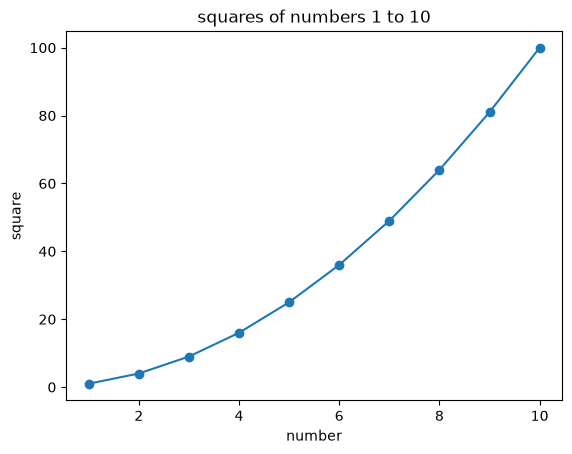

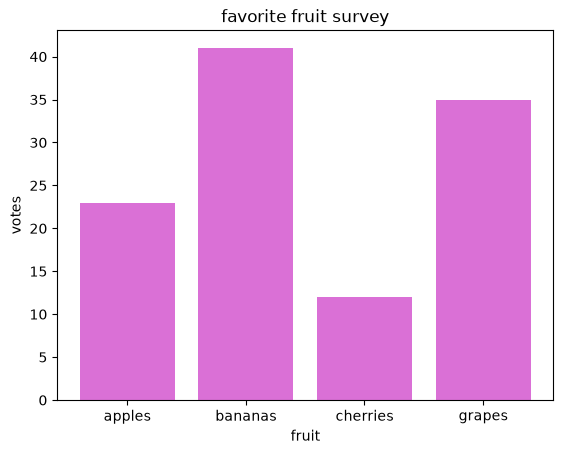

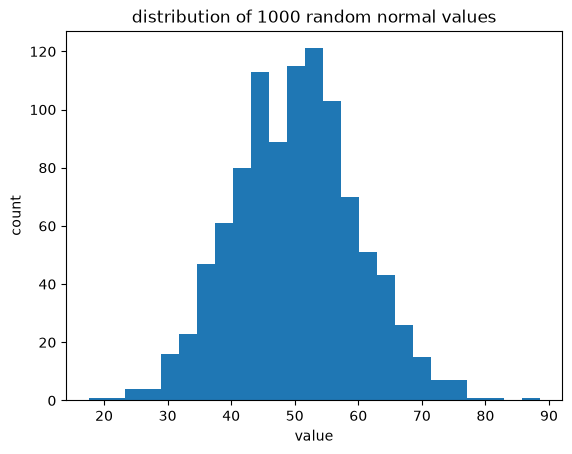

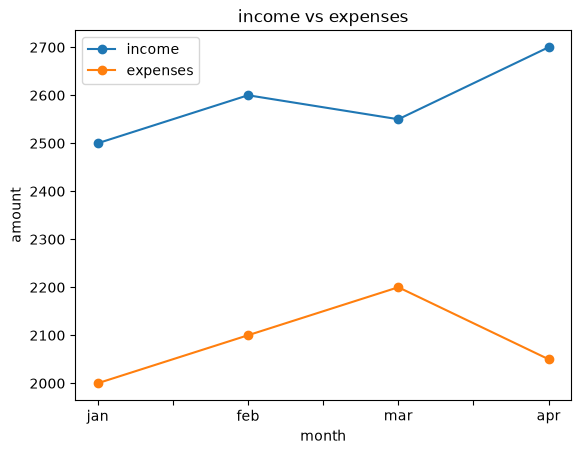

In [11]:
# sample solution 1
numbers = list(range(1, 11))          # 1 to 10
squares = [n ** 2 for n in numbers]   # the square of each number, using a list comprehension from lesson 03
plt.plot(numbers, squares, marker="o")
plt.title("squares of numbers 1 to 10")
plt.xlabel("number")
plt.ylabel("square")
plt.show()

# sample solution 2
fruits = ["apples", "bananas", "cherries", "grapes"]
votes = [23, 41, 12, 35]  # made-up "favorite fruit" vote counts
plt.bar(fruits, votes, color="orchid")
plt.title("favorite fruit survey")
plt.xlabel("fruit")
plt.ylabel("votes")
plt.show()

# sample solution 3
np.random.seed(42)  # fixed seed for reproducibility
sample_values = np.random.normal(loc=50, scale=10, size=1000)
plt.hist(sample_values, bins=25)
plt.title("distribution of 1000 random normal values")
plt.xlabel("value")
plt.ylabel("count")
plt.show()

# sample solution 4
finances = pd.DataFrame({
    "month": ["jan", "feb", "mar", "apr"],
    "income": [2500, 2600, 2550, 2700],
    "expenses": [2000, 2100, 2200, 2050],
})
finances = finances.set_index("month")
finances.plot(kind="line", marker="o", title="income vs expenses")
plt.ylabel("amount")
plt.show()

* congratulation you finished this lesson

## what we learned
* WHY visualization matters - a chart reveals patterns/outliers a table of numbers hides, and matplotlib is the foundational library almost every other python plotting tool builds on
* the basic anatomy of a matplotlib plot: `plt.plot()`, `plt.title()`/`plt.xlabel()`/`plt.ylabel()`, `plt.legend()`, `plt.show()`
* the four classic chart types: line plots, bar charts, scatter plots and histograms - and when to reach for each one
* `plt.subplots(rows, cols)` to lay out several charts side by side in one figure
* customizing appearance: `color=`, `marker=`, `linestyle=`, `figsize=`, `plt.grid(True)`
* plotting DIRECTLY from a pandas `Series`/`DataFrame` with `.plot(kind=...)` - and that it returns a normal matplotlib `Axes` object under the hood
* saving a chart to a file with `plt.savefig()`, and always cleaning up generated files afterwards
* seaborn (nicer statistical-plot defaults on top of matplotlib) and plotly/bokeh (interactive, browser-based charts) as natural next steps beyond matplotlib